In [17]:
import xesmf
import xarray as xr
import os
import cmocean as cm
import cartopy.crs as ccrs
import cosima_cookbook as cc
from dask.distributed import Client
import dask.array as da
import numpy as np
from osgeo import gdal
import matplotlib.pyplot as plt

from pyproj import Transformer
from pyproj import CRS
ps_to_ll = Transformer.from_crs( "EPSG:3031","EPSG:4326", always_xy=True) 

In [8]:
# Open dataset
dataset = gdal.Open('/g/data1a/tm70/ek4684/Bedmachine_data/Charrassin_data/BED_ANTGG2022.tif')
band = dataset.GetRasterBand(1)
data = band.ReadAsArray()

# Get GeoTransform and projection
gt = dataset.GetGeoTransform()
nx, ny = dataset.RasterXSize, dataset.RasterYSize

# Build coordinates from geotransform
x = np.arange(gt[0], gt[0] + nx * gt[1], gt[1])
y = np.arange(gt[3], gt[3] + ny * gt[5], gt[5])

# y is descending if gt[5] < 0 (common for north-up images), reverse if needed
if gt[5] < 0:
    y = y[::-1]
    data = data[::-1, :]  # Flip data accordingly

In [9]:
print("Driver: ", ds.GetDriver().ShortName)
print("Size: ", ds.RasterXSize, ds.RasterYSize)
print("Bands: ", ds.RasterCount)
print("Projection: ", ds.GetProjection())
print("GeoTransform: ", ds.GetGeoTransform())

Driver:  GTiff
Size:  13333 13333
Bands:  1
Projection:  PROJCS["WGS 84 / Antarctic Polar Stereographic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",-71],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",NORTH],AXIS["Northing",NORTH]]
GeoTransform:  (-3333250.0, 500.0, 0.0, 3333250.0, 0.0, -500.0)


In [10]:
da = xr.DataArray(
    data,
    dims=('y', 'x'),
    coords={'x': x, 'y': y},
    attrs={
        'crs': dataset.GetProjection(),
        'transform': gt,
        'nodata': band.GetNoDataValue()
    }
)

In [11]:
ds_xr = xr.Dataset({'elevation': da})

In [21]:
ds_xr

<xarray.Dataset> Size: 711MB
Dimensions:    (x: 13333, y: 13333)
Coordinates:
  * x          (x) float64 107kB -3.333e+06 -3.333e+06 ... 3.332e+06 3.333e+06
  * y          (y) float64 107kB -3.333e+06 -3.332e+06 ... 3.333e+06 3.333e+06
Data variables:
    elevation  (y, x) float32 711MB -4.625e+03 -4.615e+03 ... -3.971e+03

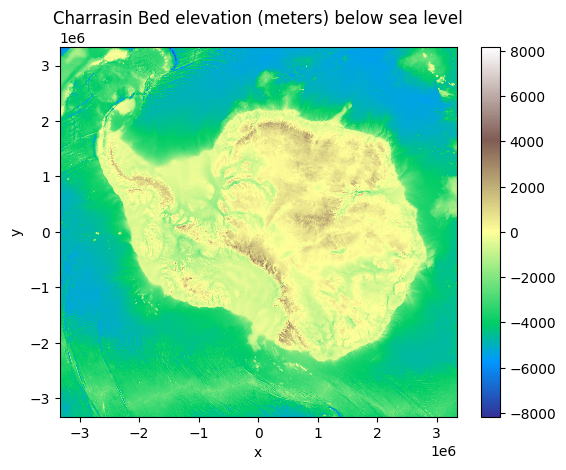

In [14]:
da.plot(cmap='terrain')
plt.title("Charrasin Bed elevation (meters) below sea level")
plt.savefig("/g/data1a/tm70/ek4684/Bedmachine_data/Charrasin_BED_elevation.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Create 2D coordinate grids
X, Y = np.meshgrid(x, y)

# Flatten and transform
lon_flat, lat_flat = ps_to_ll.transform(X.ravel(), Y.ravel())
lon_flat = (lon_flat + 180) % 360 - 180  # Normalize longitudes

# Reshape to 2D
new_longitudes = lon_flat.reshape(X.shape)
new_latitudes = lat_flat.reshape(Y.shape)

In [23]:
ds_out = xr.Dataset(
    data_vars={
        "elevation": (("y", "x"), ds_xr.elevation.data)
    },
    coords={
        "lat": (("y", "x"), new_latitudes),
        "lon": (("y", "x"), new_longitudes)
    },
    attrs={
        "title": "Bedmachine Antarctic Topography",
        "source_crs": "EPSG:3031",
        "converted_to": "EPSG:4326",
        "note": "Original Charrassin Bed elevation data was in polar stereographic projection and converted to lat/lon."
    }
)

ds_out["elevation"].attrs["units"] = "meters"
ds_out["elevation"].attrs["long_name"] = "Surface elevation"
ds_out["lat"].attrs["units"] = "degrees_north"
ds_out["lon"].attrs["units"] = "degrees_east"
ds_out.to_netcdf("/g/data1a/tm70/ek4684/Bedmachine_data/Charrassin_BED_Elevation_lat_lon.nc")

In [24]:
topog = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/share/grids/2025.02.17/topog.nc', decode_times=False).rename({'geolon_t': 'lon', 'geolat_t': 'lat'})

In [25]:
Charrassin_Bed_elevation_data = xr.open_dataset('/g/data/tm70/ek4684/Bedmachine_data/Charrassin_BED_Elevation_lat_lon.nc', decode_times=False)

In [28]:
#Re-using the weights created for Bedmachine_v2 to model grid, since both the Charrassin and Bedmachine_v2 has same resolution (500m*500m) and same projection EPSG3031.
regridder_Bed_machine_to_GEBCO = xesmf.Regridder(
    Charrassin_Bed_elevation_data,
    topog,
    "bilinear",
    periodic=True,
    filename='/g/data1a/tm70/ek4684/Bedmachine_data/Regridd_Bedmachine_to_model_grid_Bilinear.nc',
    reuse_weights=True)

In [29]:
Elevation = regridder_Bed_machine_to_GEBCO(Charrassin_Bed_elevation_data.elevation)

In [30]:
Elevation = Elevation.assign_coords(lat=topog['lat'], lon=topog['lon'])
Elevation = Elevation.where(Elevation.lat <= -60, drop=True)

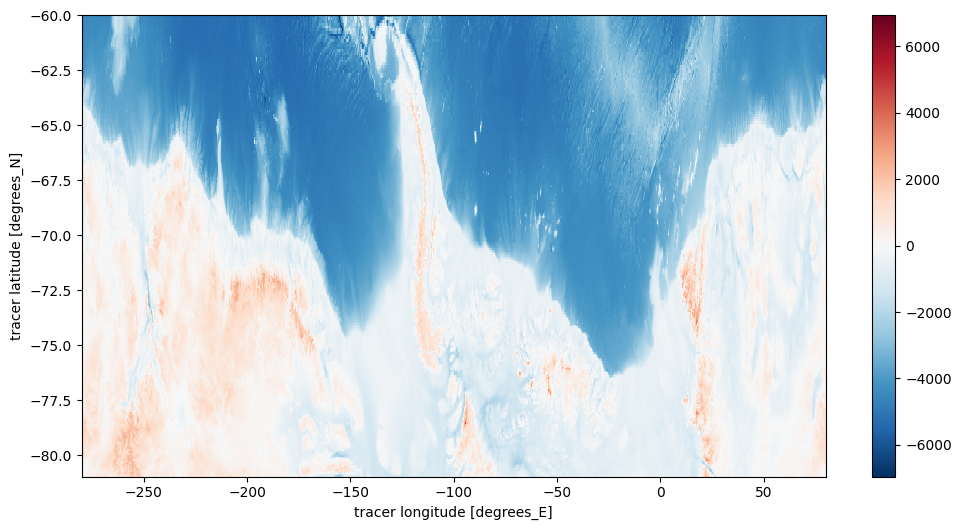

In [32]:
plt.figure(figsize=(12, 6))# You can adjust the width (12) and height (6) as needed
Elevation.plot(x='lon', y='lat')
plt.savefig("/g/data1a/tm70/ek4684/Bedmachine_data/elevation_from_Charrassin_on_model_grid.png", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
Elevation = regridder_Bed_machine_to_GEBCO(Charrassin_Bed_elevation_data.elevation)

In [34]:
diff_in_elevation = -1*Elevation - topog.depth

In [35]:
diff_in_elevation = diff_in_elevation.assign_coords(lat=topog['lat'], lon=topog['lon'])
diff_in_elevation = diff_in_elevation.where(diff_in_elevation.lat <= -60, drop=True)

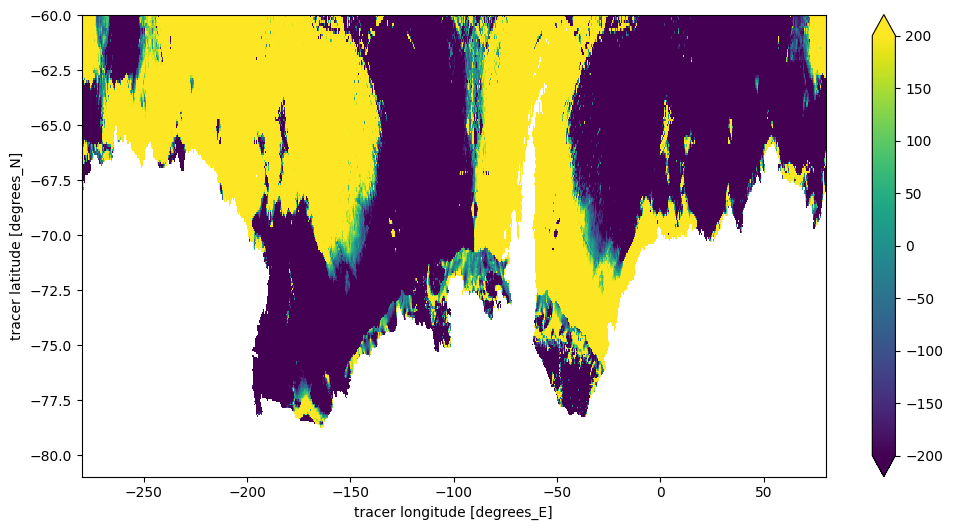

In [36]:
plt.figure(figsize=(12, 6))# You can adjust the width (12) and height (6) as needed
diff_in_elevation.plot(x='lon', y='lat', vmax=200,vmin =-200)
plt.savefig("/g/data1a/tm70/ek4684/Bedmachine_data/elevation_difference_Charrasin_topog.png", dpi=300, bbox_inches='tight')
plt.show()

In [37]:
Bed_machine_data = xr.open_dataset('/g/data/tm70/ek4684/Bedmachine_data/BedMachineAntarctica_2020-07-15_v02_pyproj.nc', decode_times=False)

In [38]:
regridder_Bed_machine_to_GEBCO = xesmf.Regridder(
    Bed_machine_data,
    topog,
    "bilinear",
    periodic=True,
    filename='/g/data1a/tm70/ek4684/Bedmachine_data/Regridd_Bedmachine_to_model_grid_Bilinear.nc',
    reuse_weights=True)

In [39]:
Bed = regridder_Bed_machine_to_GEBCO(Bed_machine_data.bed)

In [40]:
diff_in_elevation = Elevation - Bed

In [42]:
diff_in_elevation = diff_in_elevation.assign_coords(lat=topog['lat'], lon=topog['lon'])
diff_in_elevation = diff_in_elevation.where(diff_in_elevation.lat <= -60, drop=True)

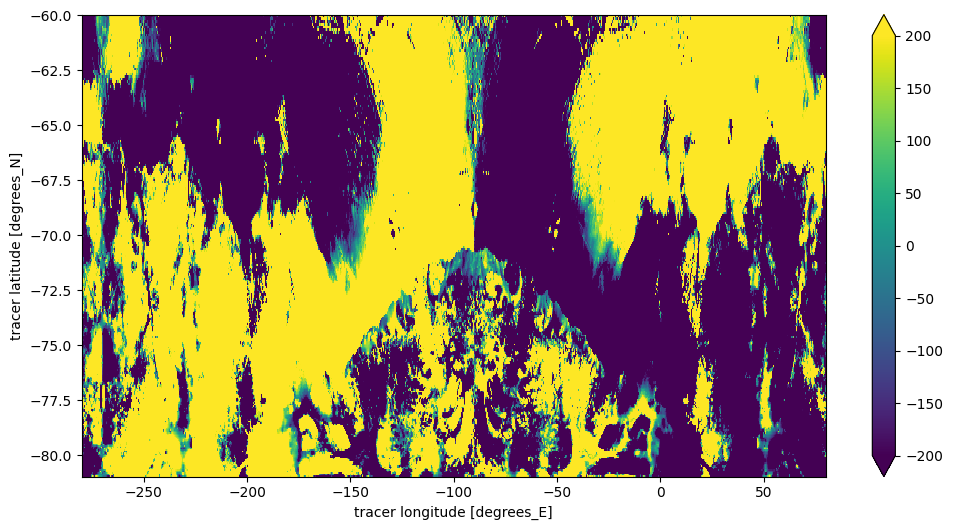

In [44]:
#Plot the difference betweeen Regridded Charrassin and Bedmachine_v2 data
plt.figure(figsize=(12, 6))# You can adjust the width (12) and height (6) as needed
diff_in_elevation.plot(x='lon', y='lat', vmax=200,vmin =-200)
plt.savefig("/g/data1a/tm70/ek4684/Bedmachine_data/elevation_difference_Charrasin_Bedmachine_v2.png", dpi=300, bbox_inches='tight')
plt.show()